In [ ]:
# requires gseapy:
# pip install gseapy

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

/tmp/ipykernel_152171/3456385673.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


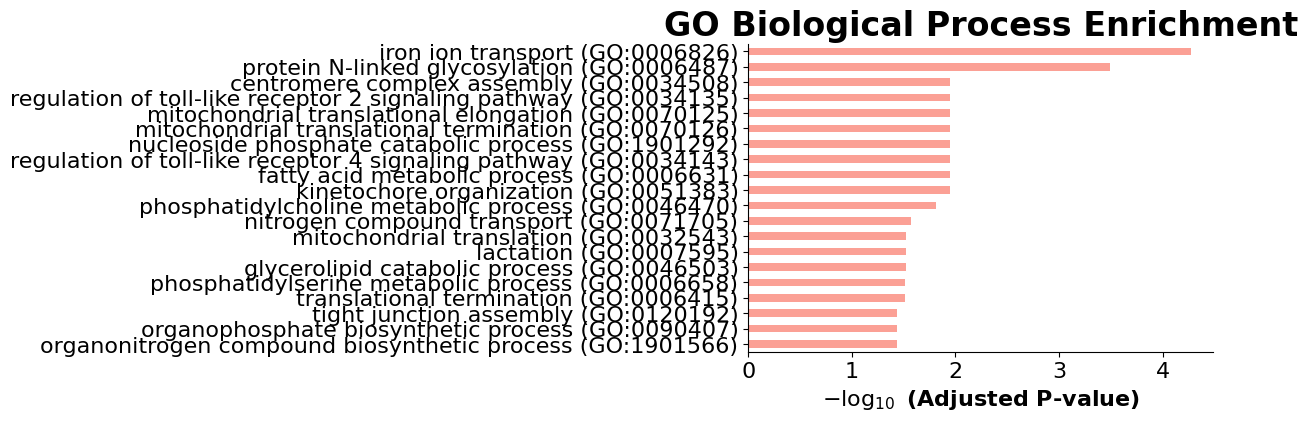

In [ ]:
# GO and KEGG pathway enrichment analysis using gseapy
project_dir = Path.cwd().parent
deg_matrix = pd.read_csv(project_dir / "quants" / "GSE60450_deseq2_results.csv", index_col=0)

# Filter gene list for GO/KEGG analysisbased on adjusted p-value and log2 fold change
deg_significant_matrix_up = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] > 1)].copy()
gene_list_up = deg_significant_matrix_up["gene_name"].dropna().astype(str).drop_duplicates().tolist()
deg_significant_matrix_down = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] < -1)].copy()
gene_list_down = deg_significant_matrix_down["gene_name"].dropna().astype(str).drop_duplicates().tolist()


# Perform GO enrichment analysis for upregulated genes
go_enrichment_up = gp.enrichr(
    gene_list=gene_list_up,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_enrichment_up.results.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_up_results.csv", index=False)

# Perform GO enrichment analysis for downregulated genes
go_enrichment_down = gp.enrichr(
    gene_list=gene_list_down,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_enrichment_down.results.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_down_results.csv", index=False)

# plot with matplotlib / seaborn
